## 1 Lecture images

In [1]:
from skimage.io import imread, imshow
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog
import matplotlib.pyplot as plt
import numpy as np
import os # Permet d'accéder aux répertoires et fichiers

In [9]:
# Chemin d'accès du repertoire courant
rep = os.getcwd()
print(rep)

c:\Users\HP\Formation Machine Learning\image_classification


In [10]:
# Lister les éléments du répertoire courant
v = os.listdir(rep)

for i in range(len(v)):
     print(f"{i}: {v[i]}")

0: AnimalFacesClassification.html
1: animals_faces_classification.ipynb
2: BearHead
3: CatHead
4: CowHead
5: DeerHead
6: elephant.jpg


In [11]:
# Lecture images BearHead
BearHead = []

In [13]:
# creation du chemin d'accès au dossier contenant les images BearHead
way1 = os.path.join(rep, os.listdir(rep)[2])
print(way1)

c:\Users\HP\Formation Machine Learning\image_classification\BearHead


In [14]:
for img in os.listdir(way1):
    image= imread(os.path.join(way1, img), as_gray= True)
    image= resize(image, (128, 64))
    BearHead.append(image)
    #print(BearHead)

In [15]:
CatHead= []

# creation du chemin d'accès au dossier contenant les images CatHead
way2 = os.path.join(rep, os.listdir(rep)[3])
print(way2)

c:\Users\HP\Formation Machine Learning\image_classification\CatHead


In [16]:
for img in os.listdir(way2):
    image= imread(os.path.join(way2, img), as_gray= True)
    image= resize(image, (128, 64))
    CatHead.append(image)
    #print(CatHead)

In [17]:
CowHead= []

# creation du chemin d'accès au dossier contenant les images CowHead
way3 = os.path.join(rep, os.listdir(rep)[4])
print(way3)

c:\Users\HP\Formation Machine Learning\image_classification\CowHead


In [18]:
for img in os.listdir(way3):
    image= imread(os.path.join(way3, img), as_gray= True)
    image= resize(image, (128, 64))
    CowHead.append(image)
    #print(CowHead)

In [21]:
# Vérification des images de CowHead
all_gray = True
i = 0
for img in CowHead:
    if len(img.shape) != 2:
        i+=1
        all_gray = False

if all_gray:
    print("Toutes les images de CowHead sont en niveaux de gris et ont une dimension de 2.")
else:
    print(f"Certaines images (indice: {i}) de CowHead ne sont pas en niveaux de gris ou n'ont pas une dimension de 2.")

Certaines images (indice: 1) de CowHead ne sont pas en niveaux de gris ou n'ont pas une dimension de 2.


In [23]:
# Initialiser une liste pour stocker les indices des images qui ne sont pas en niveaux de gris
non_gray_indices = []

# Parcourir toutes les images de CowHead
for idx, img in enumerate(CowHead):
    # Vérifier si l'image n'est pas en niveaux de gris
    if len(img.shape) != 2:
        non_gray_indices.append(idx)

# Afficher les indices des images qui ne sont pas en niveaux de gris
print("Indices des images de CowHead qui ne sont pas en nuance de gris:", non_gray_indices)

Indices des images de CowHead qui ne sont pas en nuance de gris: [94]


In [24]:
# Supprimer les images de CowHead qui ne sont pas en niveaux de gris
for idx in sorted(non_gray_indices, reverse=True):
    del CowHead[idx]

In [49]:
# Vérifier les dimensions des images restantes
for idx, img in enumerate(CowHead):
    print(f"Image {idx} dimensions: {img.shape}")

Image 0 dimensions: (128, 64)
Image 1 dimensions: (128, 64)
Image 2 dimensions: (128, 64)
Image 3 dimensions: (128, 64)
Image 4 dimensions: (128, 64)
Image 5 dimensions: (128, 64)
Image 6 dimensions: (128, 64)
Image 7 dimensions: (128, 64)
Image 8 dimensions: (128, 64)
Image 9 dimensions: (128, 64)
Image 10 dimensions: (128, 64)
Image 11 dimensions: (128, 64)
Image 12 dimensions: (128, 64)
Image 13 dimensions: (128, 64)
Image 14 dimensions: (128, 64)
Image 15 dimensions: (128, 64)
Image 16 dimensions: (128, 64)
Image 17 dimensions: (128, 64)
Image 18 dimensions: (128, 64)
Image 19 dimensions: (128, 64)
Image 20 dimensions: (128, 64)
Image 21 dimensions: (128, 64)
Image 22 dimensions: (128, 64)
Image 23 dimensions: (128, 64)
Image 24 dimensions: (128, 64)
Image 25 dimensions: (128, 64)
Image 26 dimensions: (128, 64)
Image 27 dimensions: (128, 64)
Image 28 dimensions: (128, 64)
Image 29 dimensions: (128, 64)
Image 30 dimensions: (128, 64)
Image 31 dimensions: (128, 64)
Image 32 dimension

In [50]:
# Convertir les images non gris de CowHead en images de nuance de gris de dimensions (168, 64)
#for idx in non_gray_indices:
#    img = CowHead[idx]
#    gray_img = rgb2gray(img)
#    resized_img = resize(gray_img, (168, 64))
#    CowHead[idx] = resized_img

# Vérifier les dimensions des images converties
#for idx in non_gray_indices:
#    print(f"Image {idx} dimensions: {CowHead[idx].shape}")

In [26]:
DeerHead= []

# creation du chemin d'accès au dossier contenant les images DeerHead
way4 = os.path.join(rep, os.listdir(rep)[5])
print(way4)

c:\Users\HP\Formation Machine Learning\image_classification\DeerHead


In [27]:
for img in os.listdir(way4):
    image= imread(os.path.join(way4, img), as_gray= True)
    image= resize(image, (128, 64))
    DeerHead.append(image)
    #print(DeerHead)

## 2 Taille des échantillons

In [28]:
print('BearHead : ', len(BearHead))
print('CatHead : ', len(CatHead))
print('CowHead : ', len(CowHead))
print('DeerHead : ', len(DeerHead))

BearHead :  101
CatHead :  160
CowHead :  103
DeerHead :  103


## 3 Visualisation de quelques images sélectionnées aléatoirement

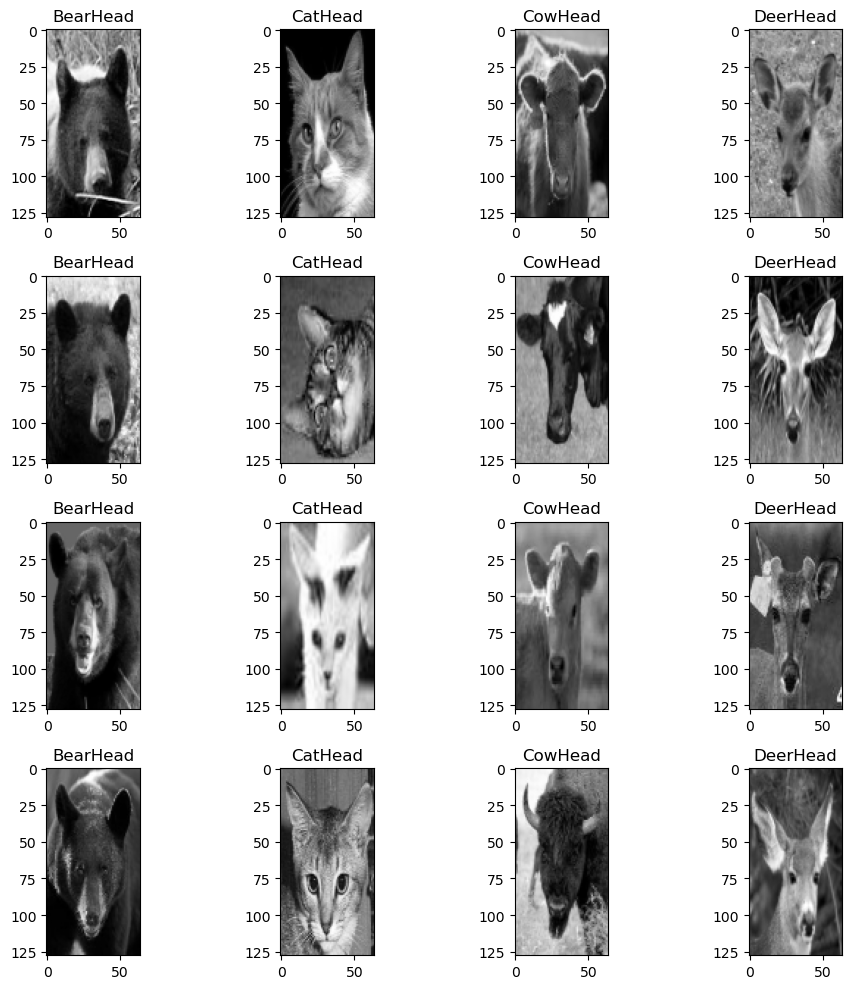

In [29]:
import random

f,axes = plt.subplots(4,4, figsize=(10,10))

for index in range(0,4):
    #BearHead
    picture= random.choice(BearHead)
    axes[index, 0].imshow(picture, cmap= "gray")
    axes[index, 0].set_title("BearHead")

    #CatHead
    picture= random.choice(CatHead)
    axes[index, 1].imshow(picture, cmap= "gray")
    axes[index, 1].set_title("CatHead")

    #CowHead
    picture= random.choice(CowHead)
    axes[index, 2].imshow(picture, cmap= "gray")
    axes[index, 2].set_title("CowHead")

    #DeerHead
    picture= random.choice(DeerHead)
    axes[index, 3].imshow(picture, cmap= "gray")
    axes[index, 3].set_title("DeerHead")

plt.tight_layout()    

In [30]:
axes.shape

(4, 4)

In [31]:
axes[0, 2]

<Axes: title={'center': 'CowHead'}>

## 4 L'Histogramme des gradients orientés (HOG)

In [32]:
from skimage.feature import hog
from skimage import data, exposure
from skimage.color import rgb2gray

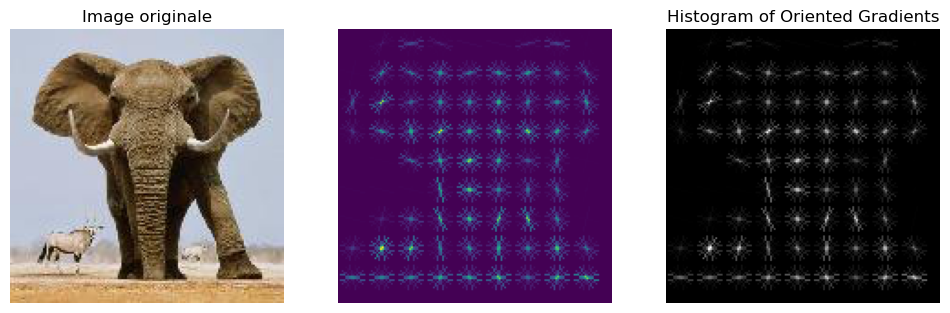

In [36]:
image_rep = os.path.join(rep, os.listdir(rep)[6])
image = imread(rf"{image_rep}")

image_gray = rgb2gray(image)

hog_datas, hog_image = hog(image_gray, orientations=8, pixels_per_cell=(16, 16),
                    cells_per_block=(1, 1), visualize=True)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 12))

ax1.axis('off')
ax1.imshow(image)
ax1.set_title('Image originale')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled)

ax3.axis('off')
ax3.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax3.set_title('Histogram of Oriented Gradients')
plt.show()

## 5 Visualisation de l'histogramme des Gradients orientés(HOG) pour quelques images


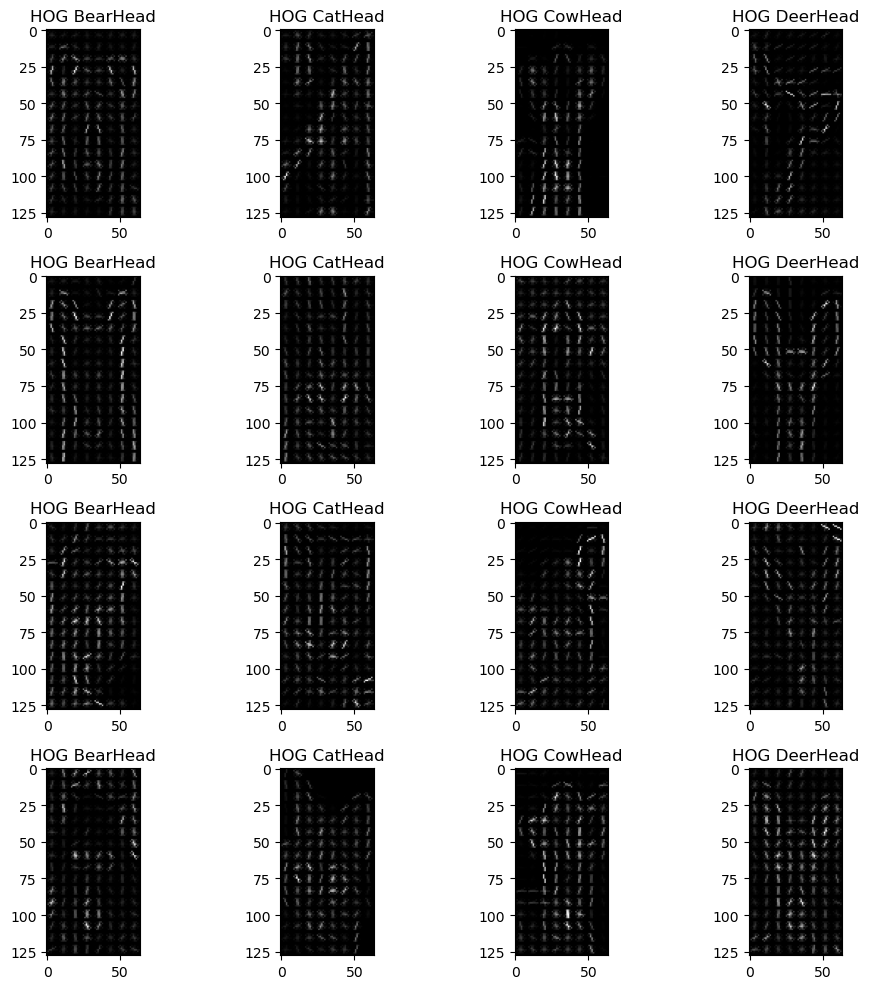

In [37]:
import random
from skimage.feature import hog

f, axes = plt.subplots(4,4, figsize=(10,10))

for index in range(0,4):
    # BearHead
    picture = random.choice(BearHead)
    
    # calcul du hog 
    hog_feature, hog_image=hog(picture,pixels_per_cell=(8,8),
                          cells_per_block=(2,2),
                          visualize=True,
                          block_norm='L2-Hys')
    
    # visualisation
    axes[index,0].imshow(hog_image, cmap='gray')
    axes[index,0].set_title("HOG BearHead")
    
    # CatHead
    picture = random.choice(CatHead)
    
    # calcul du hog 
    hog_feature, hog_image=hog(picture,pixels_per_cell=(8,8),
                          cells_per_block=(2,2),
                          visualize=True,
                          block_norm='L2-Hys')
    
    # visualisation
    axes[index,1].imshow(hog_image, cmap='gray')
    axes[index,1].set_title("HOG CatHead")
    
    # CowHead
    picture = random.choice(CowHead)
    
    # calcul du hog 
    hog_feature, hog_image=hog(picture,pixels_per_cell=(8,8),
                          cells_per_block=(2,2),
                          visualize=True,
                          block_norm='L2-Hys')
    
    # visualisation
    axes[index,2].imshow(hog_image, cmap='gray')
    axes[index,2].set_title("HOG CowHead")
    
    # DeerHead
    picture = random.choice(DeerHead)
    
    # calcul du hog 
    hog_feature, hog_image=hog(picture,pixels_per_cell=(8,8),
                          cells_per_block=(2,2),
                          visualize=True,
                          block_norm='L2-Hys')
    
    # visualisation
    axes[index,3].imshow(hog_image, cmap='gray')
    axes[index,3].set_title("HOG DeerHead")
    
plt.tight_layout()

## 6 Data preprocessing

### 6.1 Extraction des caractéristiques HOG par échantillon d'animal

In [38]:
# BearHead

hogBearHead = []

for i in BearHead:
    calcul = hog(i, pixels_per_cell=(8,8), cells_per_block = (2,2), block_norm = 'L2-Hys' )
    hogBearHead.append(calcul)
    
# conversion en matrice numpy
hogBearHead = np.array(hogBearHead)
hogBearHead.shape

(101, 3780)

In [39]:
# CatHead

hogCatHead = []

for i in CatHead:
    calcul = hog(i, pixels_per_cell=(8,8), cells_per_block = (2,2), block_norm = 'L2-Hys' )
    hogCatHead.append(calcul)
    
# conversion en matrice numpy
hogCatHead = np.array(hogCatHead)
hogCatHead.shape

(160, 3780)

In [42]:
# CowHead

hogCowHead = []

for i in CowHead:     
    calcul = hog(i, pixels_per_cell=(8,8), cells_per_block=(2,2), block_norm='L2-Hys')
    hogCowHead.append(calcul)
    
# conversion en matrice numpy
hogCowHead = np.array(hogCowHead)
hogCowHead.shape

(103, 3780)

In [40]:
# DeerHead

hogDeerHead = []

for i in DeerHead:
    calcul = hog(i, pixels_per_cell=(8,8), cells_per_block = (2,2), block_norm = 'L2-Hys' )
    hogDeerHead.append(calcul)
    
# conversion en matrice numpy
hogDeerHead = np.array(hogDeerHead)
hogDeerHead.shape

(103, 3780)

### 6.2 Assemblage des données

In [43]:
# empilement verticale des hog features des 4 échantillons
X = np.vstack((hogBearHead,hogCatHead,hogCowHead,hogDeerHead))
print(X)

[[0.16504131 0.04512696 0.25312593 ... 0.         0.14314926 0.38620812]
 [0.2918525  0.21267398 0.12586729 ... 0.09134722 0.28154887 0.29220142]
 [0.07619391 0.09260258 0.05788999 ... 0.09349691 0.24894877 0.26366554]
 ...
 [0.26938515 0.05492995 0.07183727 ... 0.24211285 0.24211285 0.07060279]
 [0.23437403 0.02728082 0.00337369 ... 0.1836983  0.25753493 0.12144181]
 [0.16161509 0.05218852 0.         ... 0.0021561  0.20299538 0.12134319]]


In [44]:
y_BearHead = np.repeat(1,hogBearHead.shape[0])
y_BearHead.shape

(101,)

In [45]:
y_CatHead = np.repeat(2,hogCatHead.shape[0])
y_CatHead.shape

(160,)

In [46]:
y_CowHead = np.repeat(3,hogCowHead.shape[0])
y_CowHead.shape

(103,)

In [47]:
y_DeerHead = np.repeat(4,hogDeerHead.shape[0])
y_DeerHead.shape

(103,)

In [48]:
# empilement horizontale des target des 4 échantillons
y = np.hstack((y_BearHead, y_CatHead, y_CowHead, y_DeerHead))
y.shape

(467,)

In [49]:
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,

In [50]:
# Visualisation des données constituées

datas = []
for i,j in zip(X,y):
    a = {'Hog Features':i, 'Target':j}
    datas.append(a)

import pandas as pd
datas = pd.DataFrame(datas)
datas

,Hog Features,Target
0,"[0.16504130909177533, 0.045126956835304724, 0....",1
1,"[0.2918524986578081, 0.21267398135092155, 0.12...",1
2,"[0.0761939093287646, 0.09260257621049636, 0.05...",1
3,"[0.11963906978755393, 0.13087363728274387, 0.1...",1
4,"[0.08211708174470643, 0.034215839453689875, 0....",1
...,...,...
462,"[0.14787643168015996, 0.08152191577016794, 0.0...",4
463,"[0.13178129327788882, 0.010038412657561415, 0....",4
464,"[0.2693851504809823, 0.05492994588051787, 0.07...",4
465,"[0.2343740341426756, 0.02728081880631634, 0.00...",4


**Enregistrer le dataset au format csv directement le dossier corrant**

#datas.to_csv('datas.csv', index=False)

In [51]:
datas.to_csv('f-datas.csv', index=False)

In [52]:
os.listdir(rep)

['AnimalFacesClassification.html',
 'animals_faces_classification.ipynb',
 'BearHead',
 'CatHead',
 'CowHead',
 'DeerHead',
 'elephant.jpg',
 'f-datas.csv']

## 6.3 Séparation des données en échantillons d'apprentissage et de test

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 2)

In [54]:
# Taille de l'échantillon d'apprentissage

print('Features >>', 'X_train :',len(X_train), '|', 'Target >>', 'y_train :', len(y_train))

Features >> X_train : 373 | Target >> y_train : 373


In [55]:
# Taille de l'échantillon test

print('Features >>', 'X_test :', len(X_test), '|', 'Target >>', 'y_test :', len(y_test))

Features >> X_test : 94 | Target >> y_test : 94


## 7 Entrainement du classifieur d'animaux

In [56]:
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [58]:
# Support Vector Machine

def classification(model):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    # Score de précision (Accuracy score)
    score = round( accuracy_score(y_test,y_pred)*100,2 )

    print(f"{model}--Score de précision--> {score} %")

model1 = SVC()
model2 = LogisticRegression()

classification(model1)
classification(model2)
    

SVC()--Score de précision--> 94.68 %
LogisticRegression()--Score de précision--> 93.62 %


## 8 Utilisation du classifieur sur d'autres images

In [59]:
from skimage.color import rgb2gray

testImages = []

for x in range(0,10):
    file = random.choice(os.listdir(way1))
    image = imread(os.path.join(way1,file))
    image = resize(image,(128,64))
    image_gray = rgb2gray(image)
    
    a = {'name':'BearHead', 'image':image, 
         'hogImage': hog(image_gray, pixels_per_cell=(8,8), cells_per_block = (2,2), block_norm = 'L2-Hys')}
    
    testImages.append(a)

In [60]:
for x in range(0,10):
    file = random.choice(os.listdir(way2))
    image = imread(os.path.join(way2,file))
    image = resize(image,(128,64))
    image_gray = rgb2gray(image)
    
    a = {'name':'CatHead', 'image':image, 
         'hogImage': hog(image_gray, pixels_per_cell=(8,8), cells_per_block = (2,2), block_norm = 'L2-Hys')}
    
    testImages.append(a)

In [61]:
for x in range(0,10):
    file = random.choice(os.listdir(way3))
    image = imread(os.path.join(way3,file))
    image = resize(image,(128,64))
    image_gray = rgb2gray(image)
    
    a = {'name':'CowHead', 'image':image, 
         'hogImage': hog(image_gray, pixels_per_cell=(8,8), cells_per_block = (2,2), block_norm = 'L2-Hys')}
    
    testImages.append(a)

In [62]:
for x in range(0,10):
    file = random.choice(os.listdir(way4))
    image = imread(os.path.join(way4,file))
    image = resize(image,(128,64))
    image_gray = rgb2gray(image)
    
    a = {'name':'DeerHead', 'image':image, 
         'hogImage': hog(image_gray, pixels_per_cell=(8,8), cells_per_block = (2,2), block_norm = 'L2-Hys')}
    
    testImages.append(a)

In [63]:
testHogImages = []

for i in testImages:
    testHogImages.append(i['hogImage'])
    
testHogImages = np.array(testHogImages)
testHogImages.shape

(40, 3780)

In [64]:
pred = model2.predict(testHogImages)
print(pred)

[1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 1 3 1 3 3 3 3 3 3 3 4 4 4 4 4 4 4
 4 4 4]


In [65]:
predRecod = []
for i in pred:
    if i == 1:
        predRecod.append('BearHead')
    elif i == 2:
        predRecod.append('CatHead')
    elif i == 3:
        predRecod.append('CowHead')
    elif i == 4:
        predRecod.append('DeerHead')
        
print(predRecod) 

['BearHead', 'BearHead', 'BearHead', 'BearHead', 'BearHead', 'BearHead', 'BearHead', 'BearHead', 'BearHead', 'BearHead', 'CatHead', 'CatHead', 'CatHead', 'CatHead', 'CatHead', 'CatHead', 'CatHead', 'CatHead', 'CatHead', 'CatHead', 'BearHead', 'CowHead', 'BearHead', 'CowHead', 'CowHead', 'CowHead', 'CowHead', 'CowHead', 'CowHead', 'CowHead', 'DeerHead', 'DeerHead', 'DeerHead', 'DeerHead', 'DeerHead', 'DeerHead', 'DeerHead', 'DeerHead', 'DeerHead', 'DeerHead']


In [66]:
for i,j in zip(testImages,predRecod):
    i['prediction'] = j
    #print(testImages)

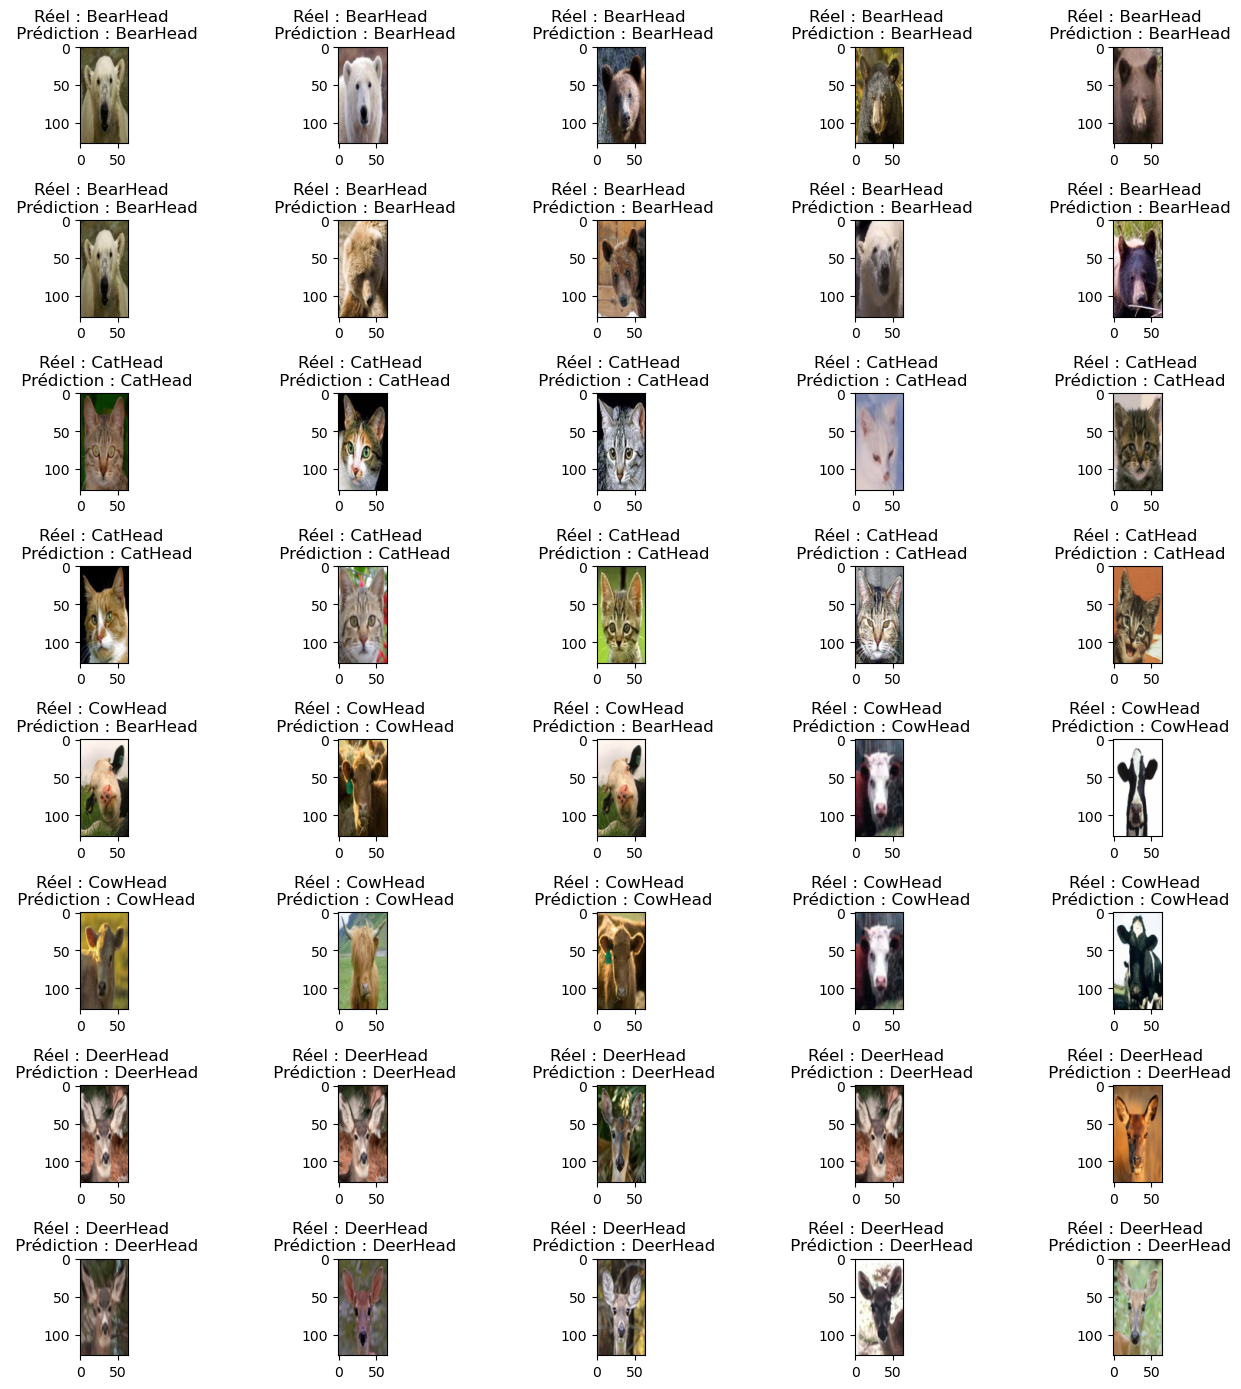

In [67]:
fig = plt.figure(figsize = (14,14))
j = 1

for i in testImages:
    plt.subplot(8,5,j)
    plt.imshow(i['image'])
    plt.title(f"Réel : {i['name']} \n Prédiction : {i['prediction']}")
    j += 1
    
plt.tight_layout()